# GAN Image Generation — Inference Demo

This notebook loads the trained Generator created by `01_GAN_Training.ipynb` and generates new images from random latent vectors.

Run the training notebook first so that `models/generator.pth` exists.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image
from PIL import Image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LATENT_SIZE = 100

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_PATH = ROOT / "models" / "generator.pth"

print("Device:", DEVICE)
print("Model:", MODEL_PATH)

Device: cpu
Model: c:\Users\user\Desktop\GAN-based-Image-Generation\models\generator.pth


In [2]:
class Generator(nn.Module):
    def __init__(self, latent_size=100, channels=3, features=64):
        super().__init__()
        self.network = nn.Sequential(
            nn.ConvTranspose2d(latent_size, features * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(features * 8, features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(features * 4, features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(features * 2, features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features),
            nn.ReLU(True),
            nn.Conv2d(features, channels, 3, 1, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, noise):
        return self.network(noise)


generator = Generator(LATENT_SIZE).to(DEVICE)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    generator.load_state_dict(checkpoint["model_state_dict"])
else:
    generator.load_state_dict(checkpoint)

generator.eval()
print("Generator loaded successfully.")

Generator loaded successfully.


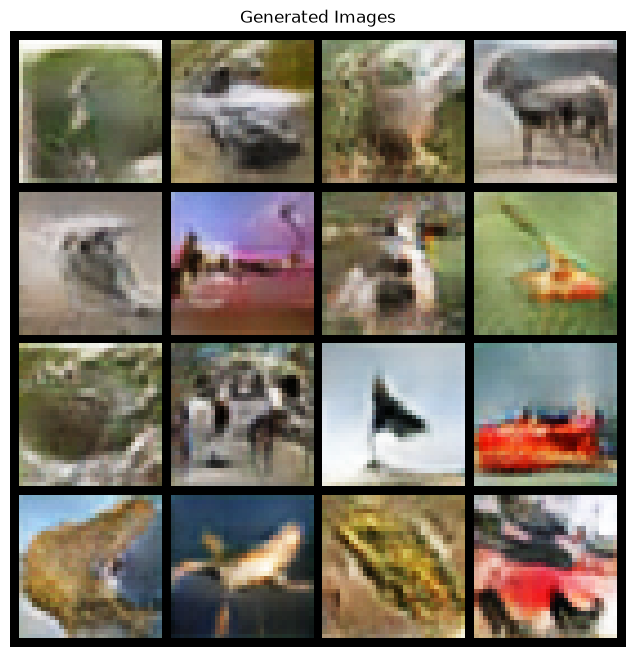

In [3]:
with torch.no_grad():
    noise = torch.randn(16, LATENT_SIZE, 1, 1, device=DEVICE)
    generated = generator(noise).cpu()

grid = make_grid(generated, nrow=4, normalize=True, padding=2)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Images")
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.show()

In [4]:
# Save the current generated grid
output_path = ROOT / "generated" / "inference_samples.png"
to_pil_image(grid).save(output_path)
print("Saved:", output_path)

Saved: c:\Users\user\Desktop\GAN-based-Image-Generation\generated\inference_samples.png


## Experiment Ideas

Try changing the number of generated images, sampling different random noise, or retraining the model with more epochs.

For a larger portfolio project, the same idea can be extended to higher-resolution datasets and more advanced GAN variants such as WGAN-GP.